In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("spaceshiptitanic_train.csv")
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [22]:

def eda(df: pd.DataFrame, target_feature: str, is_classification: bool = True):
    pd.set_option('display.max_columns', 500)

    # Separate Features
    cat_features = []
    num_features = []
    for col_name, col_data in df.items():
        if (type(col_data.dtype) in [np.dtypes.ObjectDType, np.dtypes.BoolDType]): 
            cat_features.append(col_name)
        else:
            num_features.append(col_name)

    # Basic DataFrame Info
    print("###### OVERVIEW #####")
    print("Shape:",df.shape)
    print("Columns:",list(df.columns))
    print(f"Numerical features {len(num_features)}: {num_features}")
    print(f"Categorical features {len(cat_features)}: {cat_features}")
    print("\n")

    print("###### Head #####")
    print(df.head())
    print("\n")

    # Info
    print("###### INFO #####")
    print(df.info())
    print("\n")

    # Describe
    print("###### DESCRIBE #####")
    print(df.describe())
    print("\n")

    # Duplicates
    print("###### DUPLICATES #####")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")
    print("\n")

    # Target class distribution
    print("###### Target Analysis #####")
    if is_classification:
        vc = df[target_feature].value_counts()
        vcp = 100*vc/len(df)
        for vc_index, vc_val in vc.items():
            print(f"{vc_index}: {vc_val} ({vcp[vc_index]:.2f}%)")
    else:
        df[target_feature].hist()
    print("\n")

    # Categorical Feature analysis
    print("###### Categorical Feature Analysis #####")
    for col_name, col_data in df.items():
        if col_name == target_feature: continue

        if (type(col_data.dtype) in [np.dtypes.ObjectDType, np.dtypes.BoolDType]): # Categorical
            nan_percentage = 100*col_data.isna().sum()/len(df)
            nan_str = f"{nan_percentage:.2f}%" if nan_percentage else "0%"
            print(f"{col_name}: {col_data.nunique()} categories ({nan_str} NaN)")
            if len(col_data.value_counts(dropna=False)) < 10:
                vc = col_data.value_counts()
                vcp = 100*vc/len(df)
                for vc_index, vc_val in vc.items():
                    print(f"- {vc_index}: {vc_val} ({vcp[vc_index]:.2f}%)")
            print("")
        elif (type(col_data.dtype) in [np.dtypes.Float64DType, np.dtypes.Int64DType]): # Numerical
            continue
        else:
            raise NotImplementedError(f"Have not implemented parsing for dtype: {type(col_data.dtype)}")
    print("")

    # Null analysis
    print("###### NaN Analysis #####")

    ## Row number of NaN
    n_nan = df.isna().any(axis=1).sum() # rows
    n_nan_features = df.isna().sum()
    print(f"Number of rows containing at least one NaN: {n_nan} ({100*n_nan/len(df):.2f}%)")
    for col_name, col_data in df.isna().sum(axis=1).value_counts().sort_index().items():
        if col_name:
            print(f"- {col_name}: {col_data} ({100*col_data/len(df):.2f}%)")
    print("")

    ## Feature wise NaN
    print("NaN per feature")
    for col_name, col_data in n_nan_features.items():
        print(f"- {col_name:15}: {col_data} ({100*col_data/len(df):.2f}%)")

    ## NaN correlation
    nan_mask = df.isna()
    nan_cols = nan_mask.columns[nan_mask.any()]
    nan_corr_matrix = nan_mask[nan_cols].astype(int).corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        nan_corr_matrix,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.1,
    )
    plt.title("NaN Feature Correlation")
    plt.tight_layout()
    plt.show()
    print("\n")


    # Box Plots
    print("###### Numerical Feature Box Plots #####")
    for num_feature in num_features:
        df[num_feature].plot(kind="box")
        plt.tight_layout()
        plt.grid()
        plt.show()
    print("\n")


    # Feature Distributions (Histogram & Bar plots)
    print("###### Feature Distributions #####")
    skipped_features = []
    for col_name, col_data in df.items():
        if (type(col_data.dtype) in [np.dtypes.ObjectDType, np.dtypes.BoolDType]):
            if len(col_data.value_counts(dropna=False)) < 10:
                col_data.value_counts().plot(kind="bar")
                plt.grid()
                plt.title(f"{col_name} Distribution")
                plt.xlabel("")
                plt.xticks(rotation=45)
                plt.show()
            else:
                skipped_features.append(col_name)
        elif (type(col_data.dtype) in [np.dtypes.Float64DType, np.dtypes.Int64DType]):
            col_data.plot(kind="hist", density=True)
            plt.grid()
            plt.title(f"{col_name} Histogram Distribution")
            plt.ylabel("")
            plt.axvline(x=col_data.mean(), color='black', linestyle='--')
            plt.legend([f"Max: {col_data.max():.2f}", f"$\mu$: {col_data.mean():.2f}", f"Min: {col_data.min():.2f}"])
            plt.show()
        else:
            raise NotImplementedError(f"Have not implemented parsing for dtype: {type(col_data.dtype)}")
    print(f"Skipped features due to too many categories: {skipped_features}")
    print("\n")


    # Feature Variance
    print("###### Feature Variances #####")
    variances = df[num_features].var(axis=0).sort_values(ascending=False)
    for idx, (feature, value) in enumerate(variances.items()):
        print(f"{1+idx}. {feature:15} = {value:.3e}")
    print("\n")

    # Correlation Study
    print("###### Correlation Study #####")
    corr_matrix = df.corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, vmax=1, vmin=-1, fmt=".2f", cmap="coolwarm",
                square=True, linewidths=1.0, cbar_kws={"shrink": 0.8})
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
    print("\n")

    print("###### Pair Plot #####")
    plt.figure(figsize=(8,6))
    if is_classification:
        sns.pairplot(df[num_features if (target_feature in num_features) else num_features+[target_feature]], hue=target_feature, diag_kind="kde")
    else:
        sns.pairplot(df[num_features], diag_kind="kde")
    plt.show()

###### OVERVIEW #####
Shape: (8693, 14)
Columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']
Numerical features 6: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical features 8: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']


###### Head #####
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0  

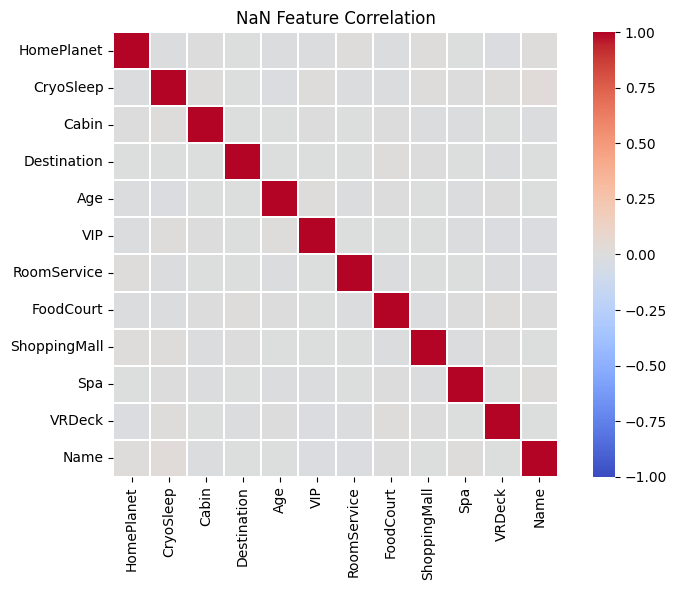



###### Numerical Feature Box Plots #####


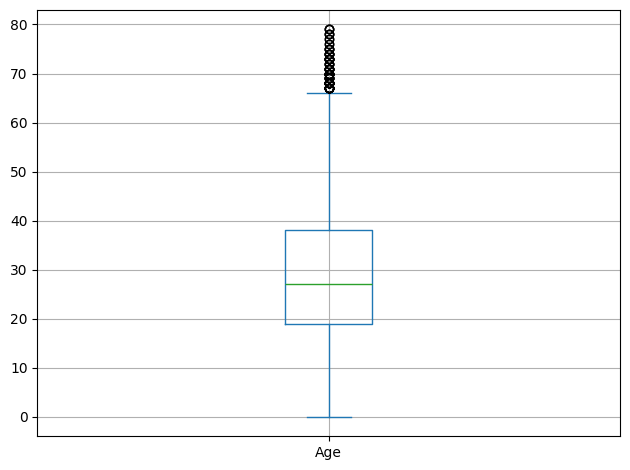

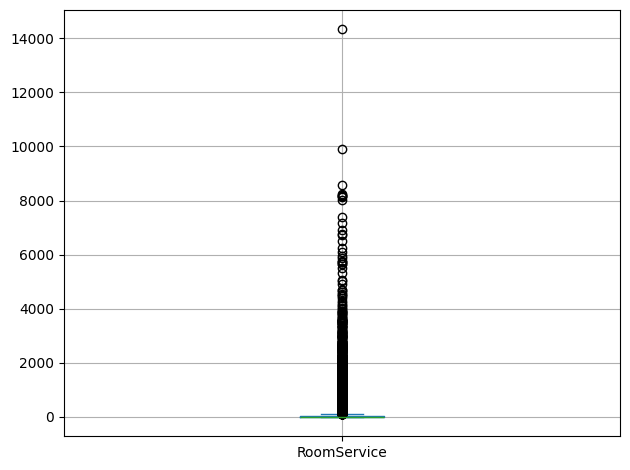

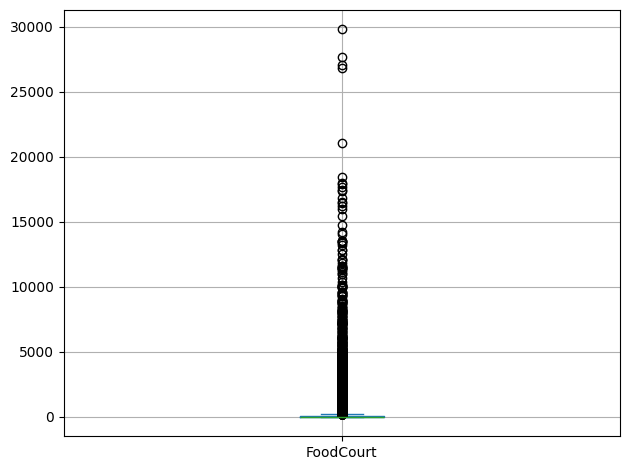

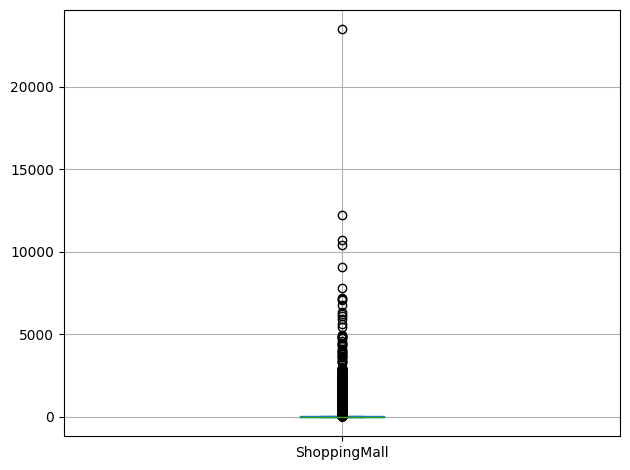

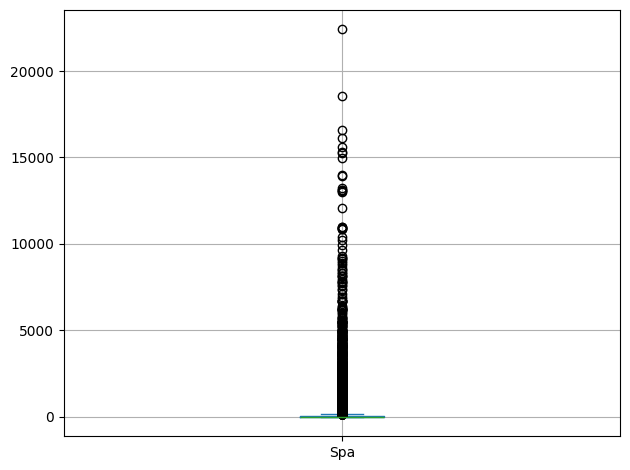

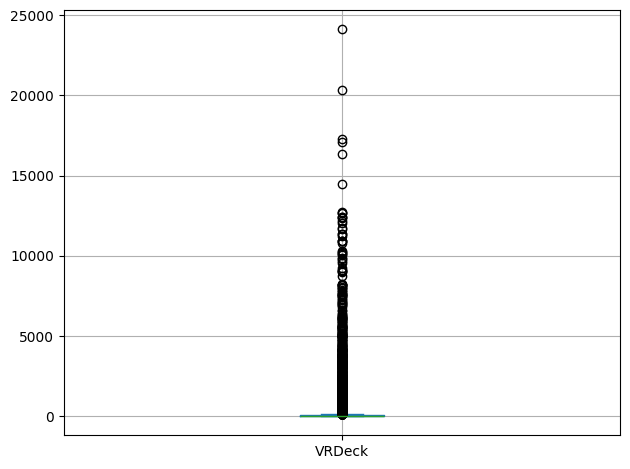



###### Feature Distributions #####


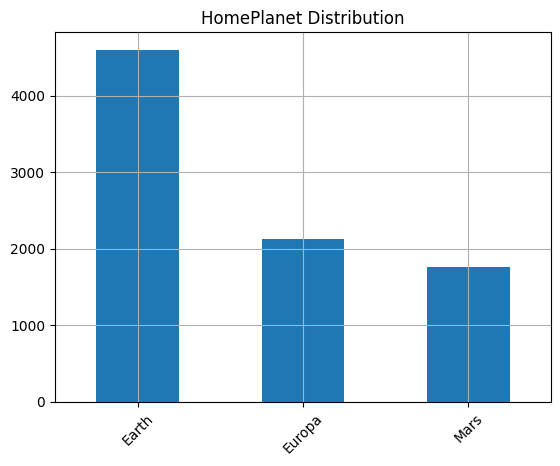

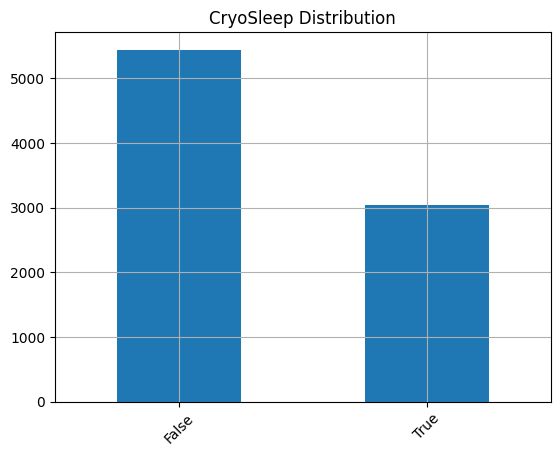

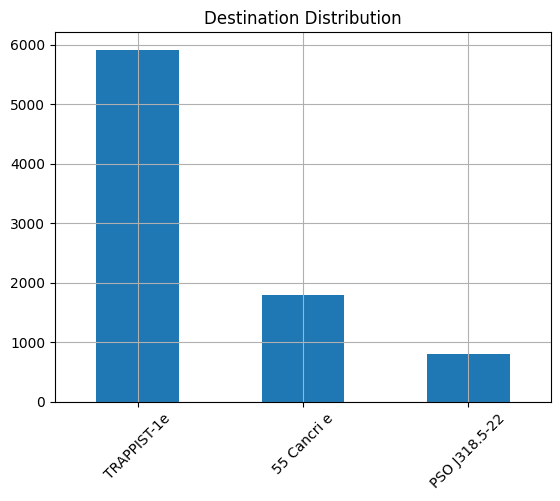

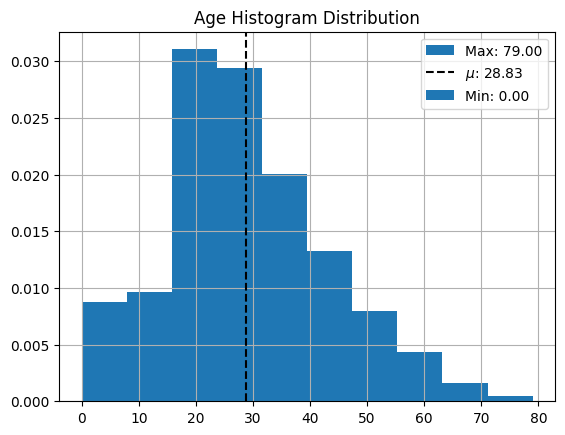

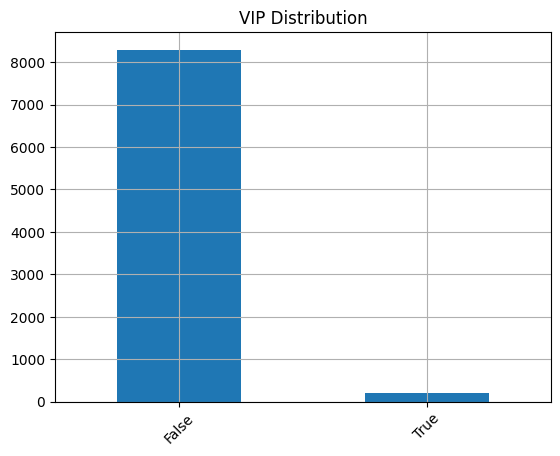

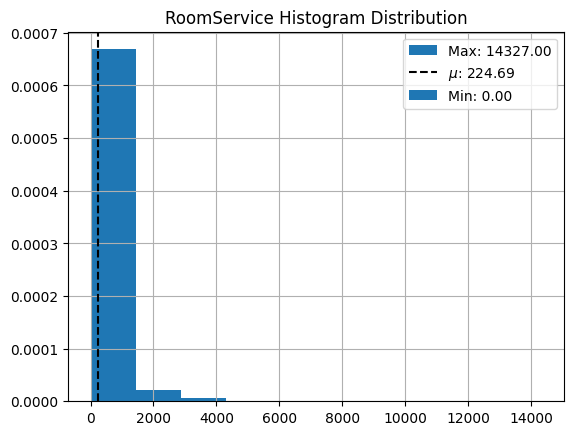

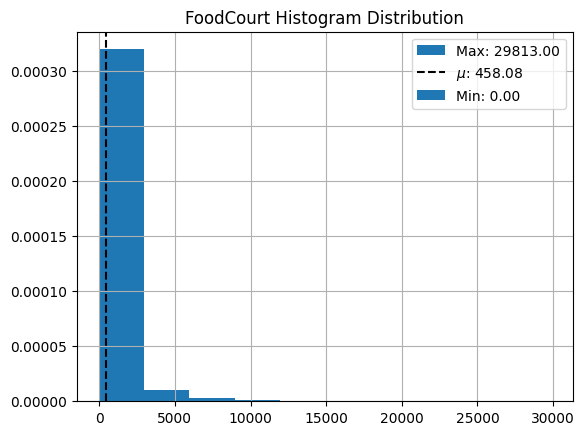

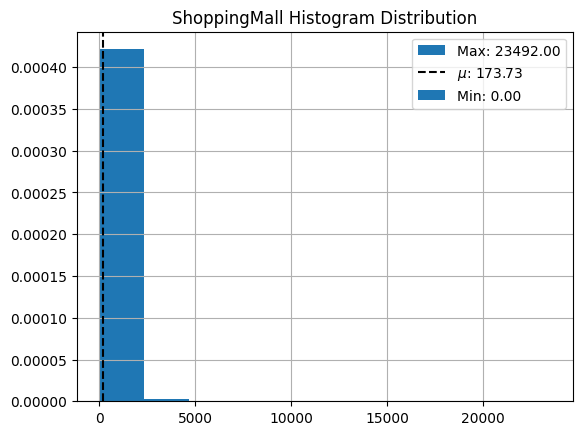

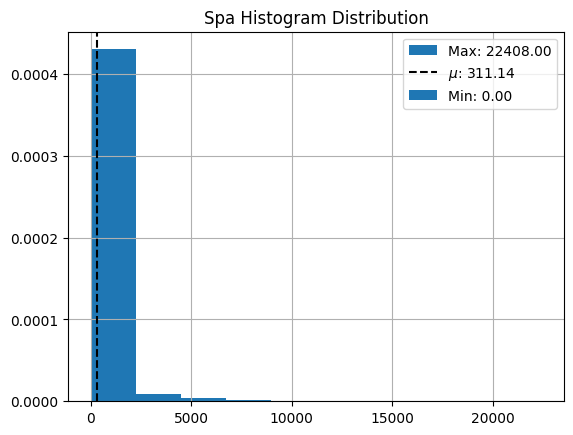

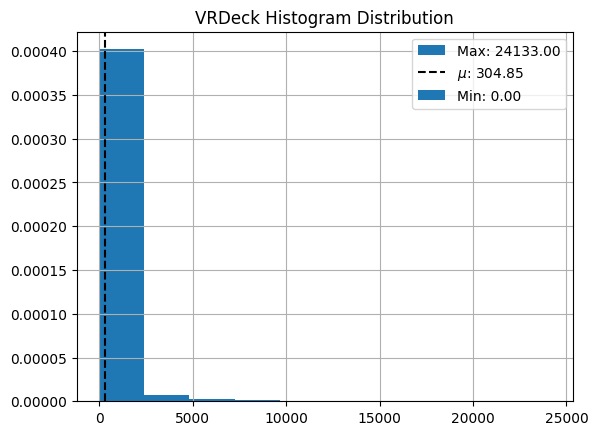

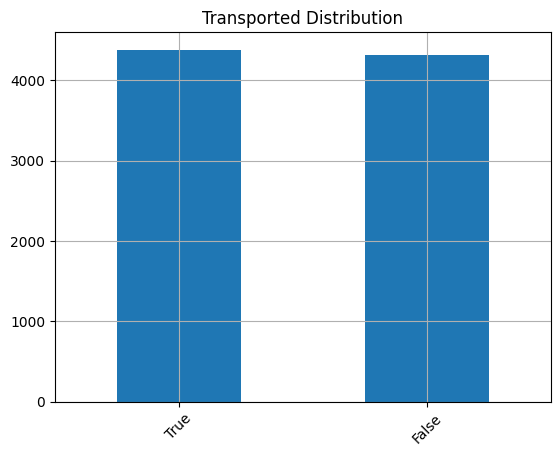

Skipped features due to too many categories: ['PassengerId', 'Cabin', 'Name']


###### Feature Variances #####
1. FoodCourt       = 2.597e+06
2. VRDeck          = 1.313e+06
3. Spa             = 1.292e+06
4. RoomService     = 4.445e+05
5. ShoppingMall    = 3.657e+05
6. Age             = 2.099e+02


###### Correlation Study #####


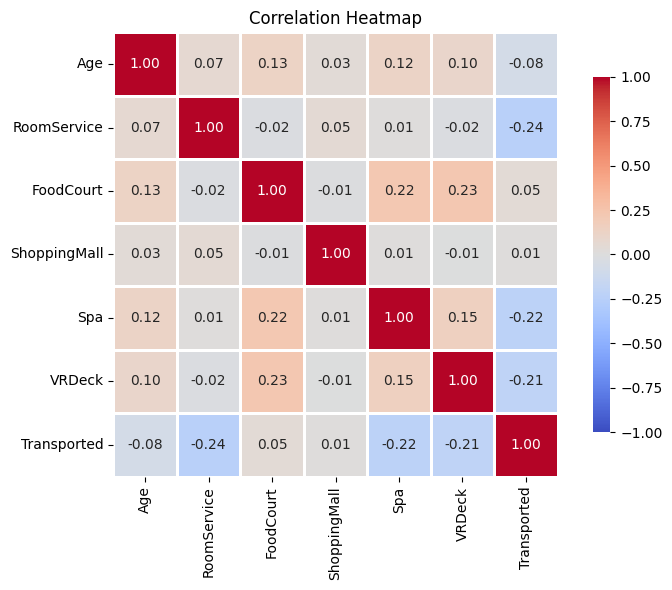



###### Pair Plot #####


<Figure size 800x600 with 0 Axes>

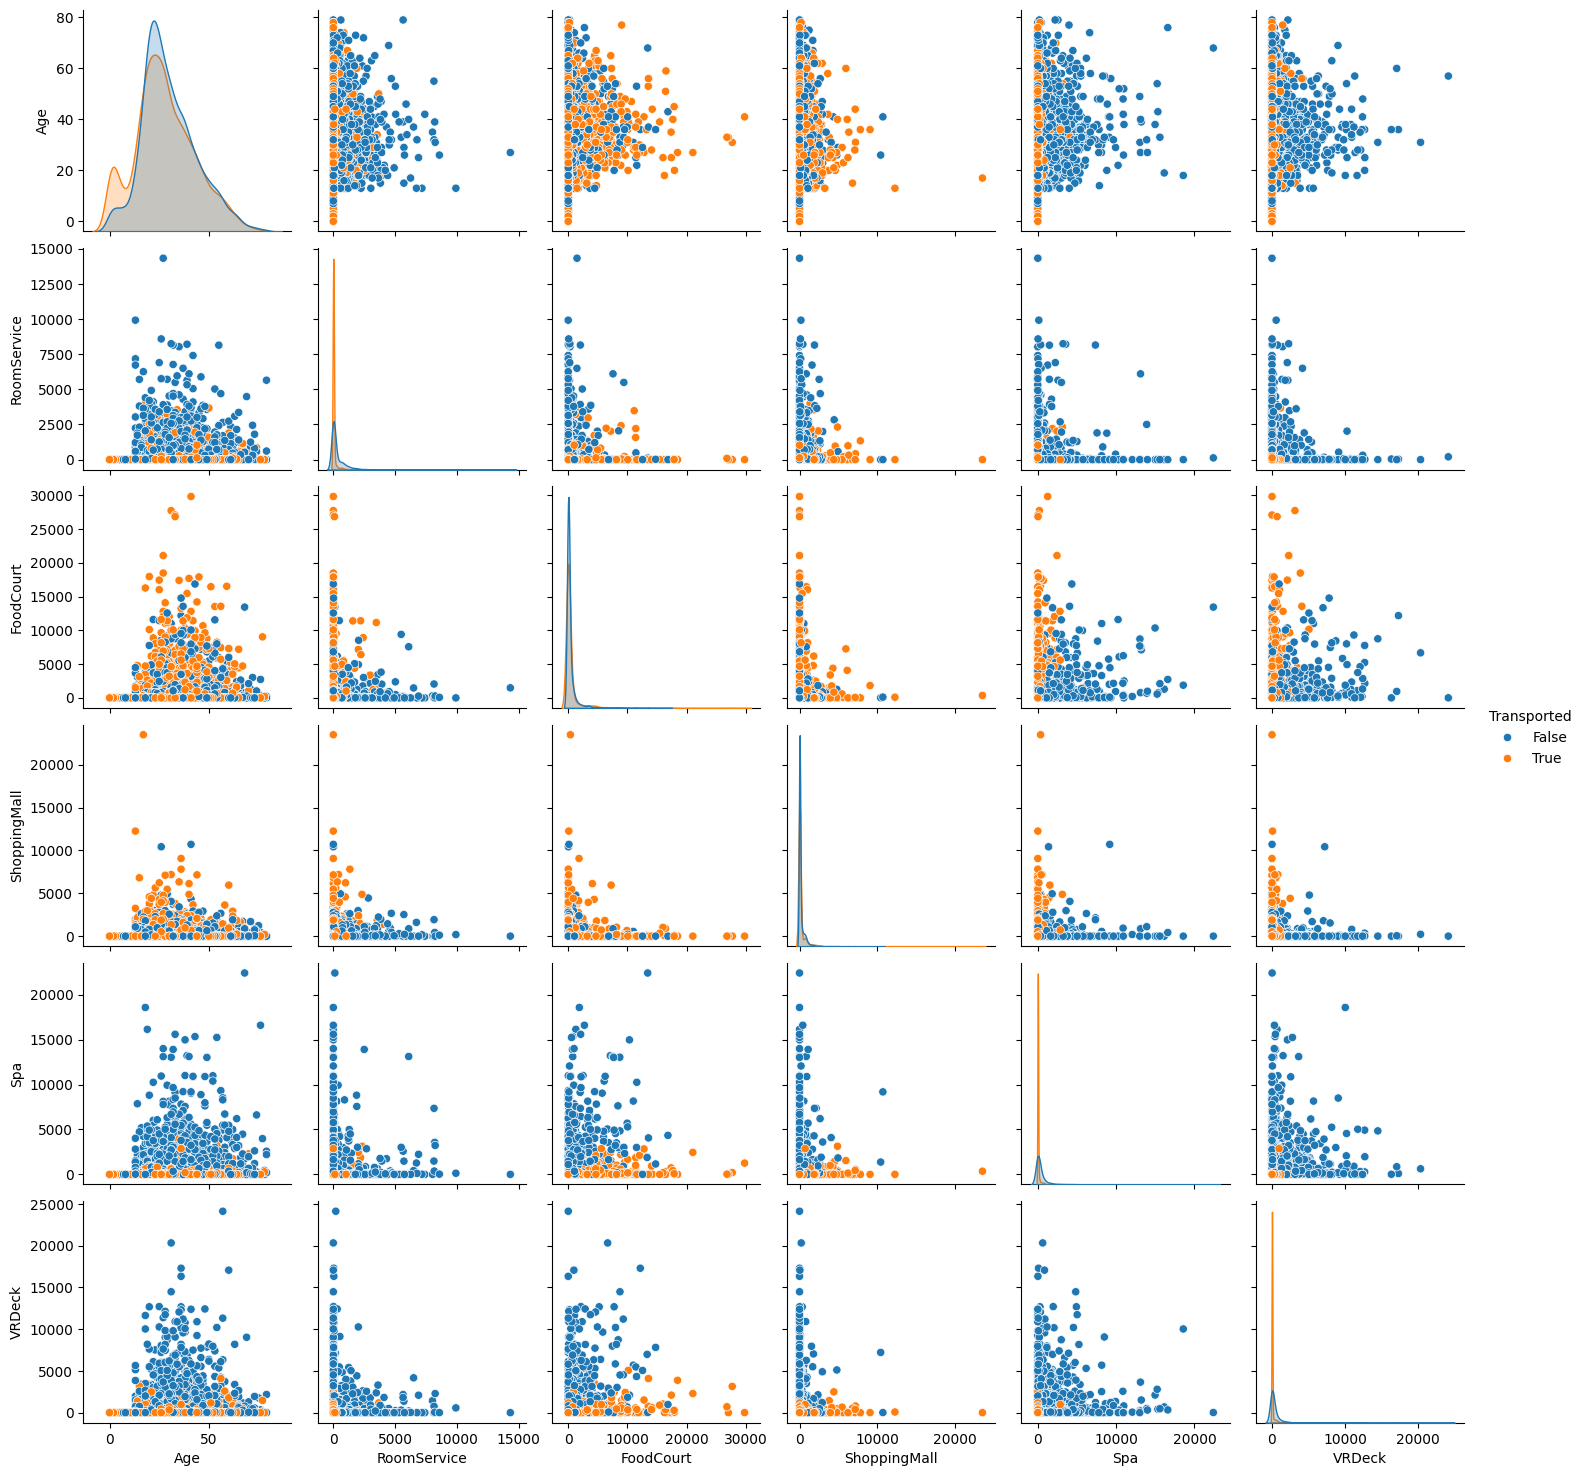

In [23]:
eda(df, "Transported")

In [24]:
df = pd.read_csv("titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###### OVERVIEW #####
Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Numerical features 7: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features 5: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


###### Head #####
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William He

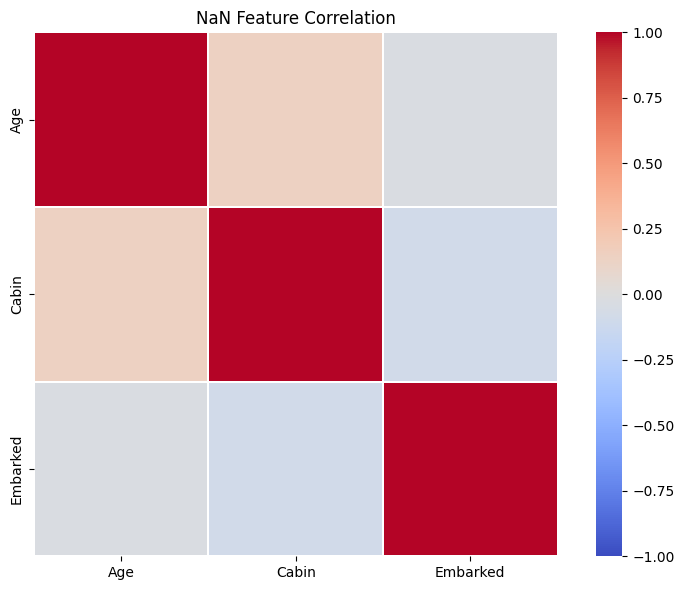



###### Numerical Feature Box Plots #####


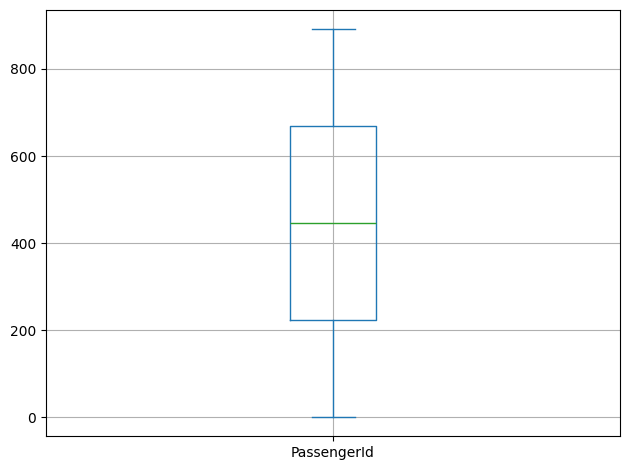

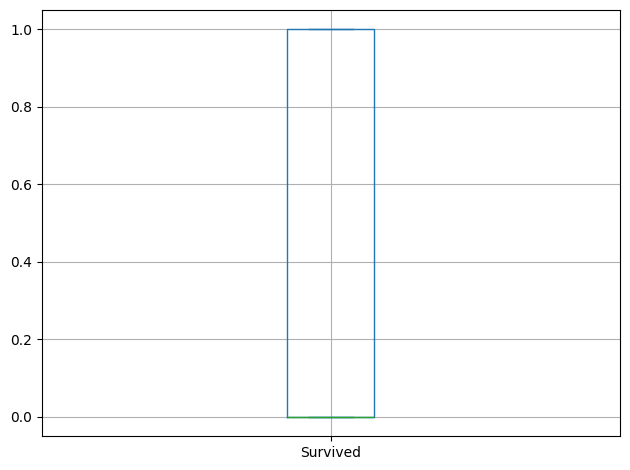

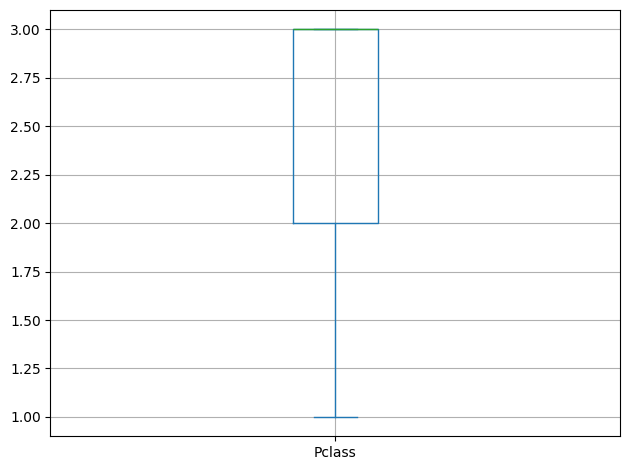

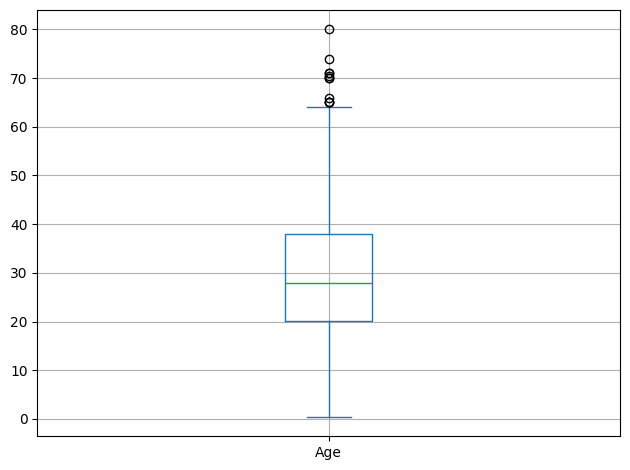

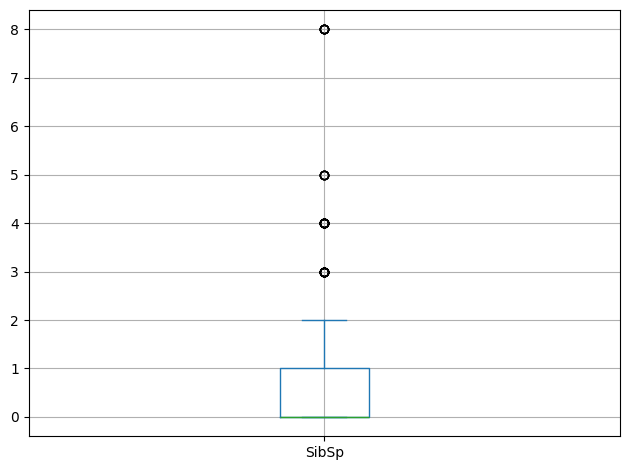

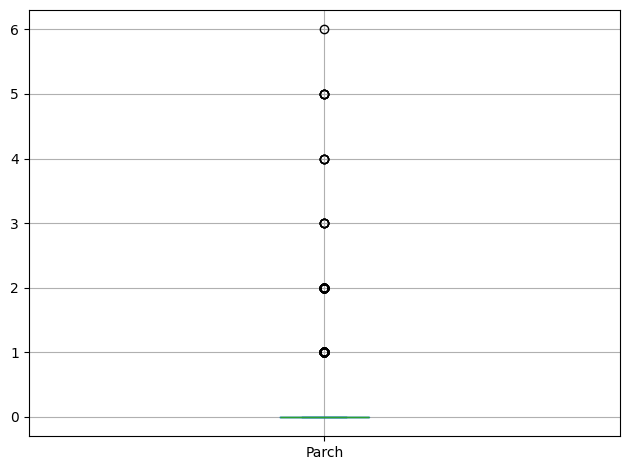

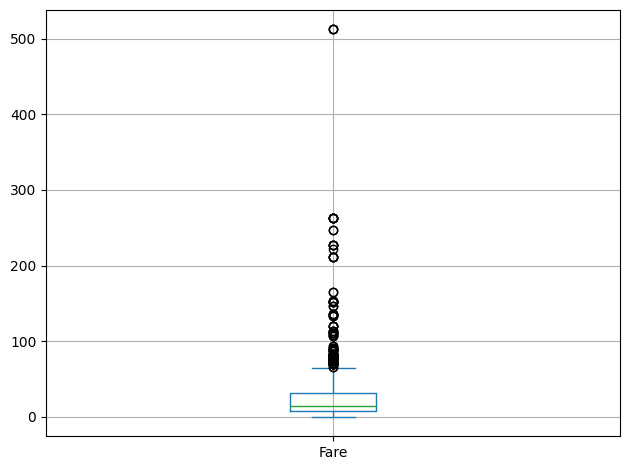



###### Feature Distributions #####


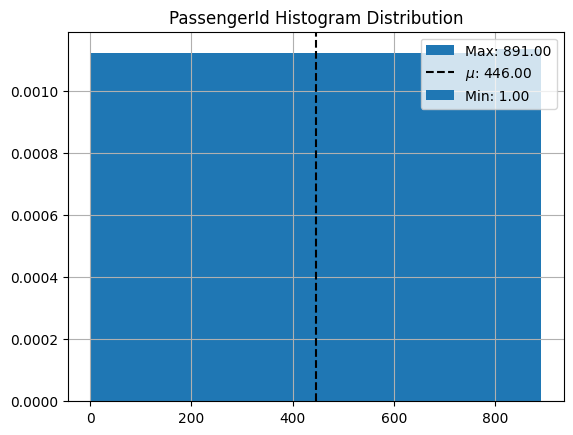

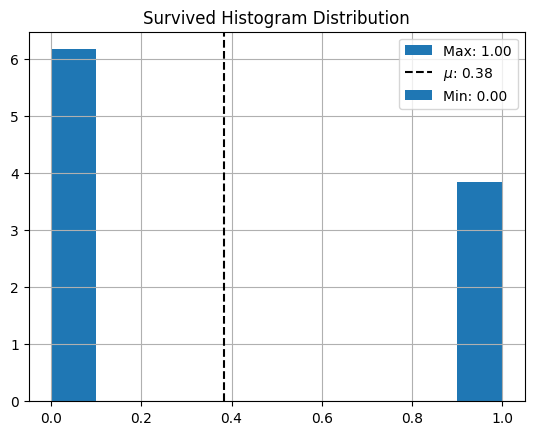

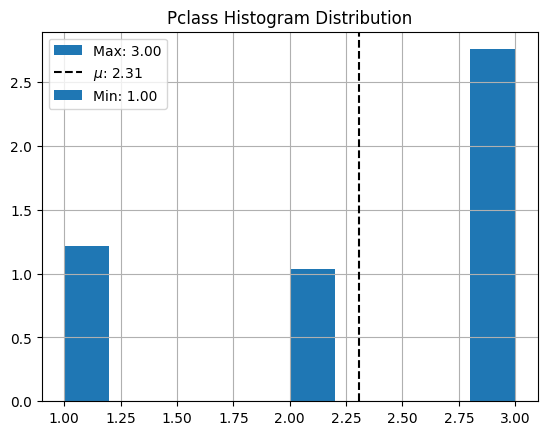

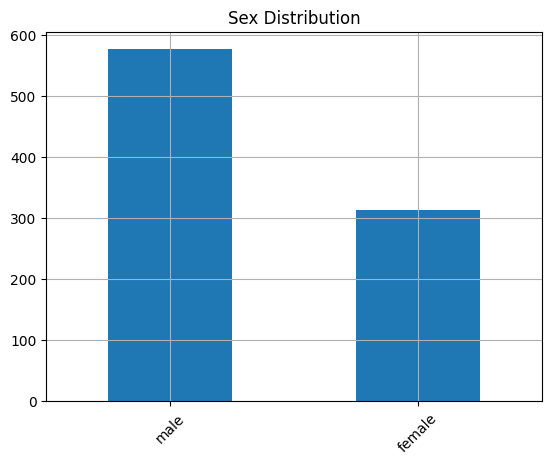

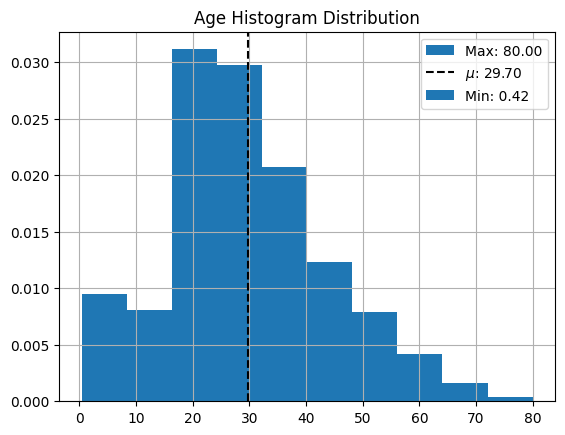

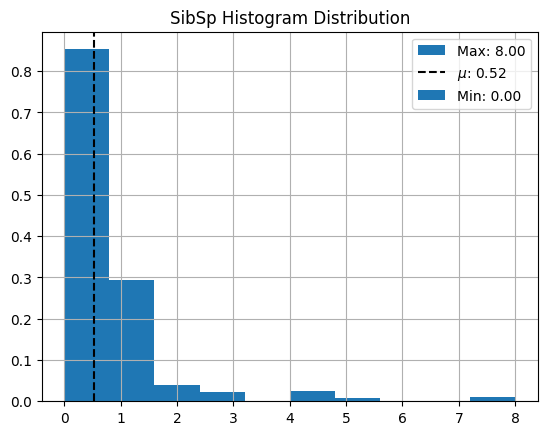

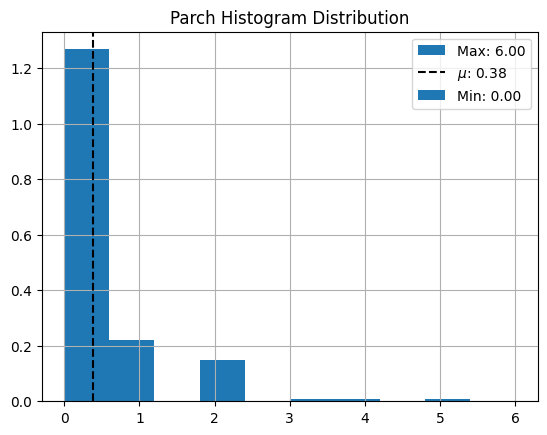

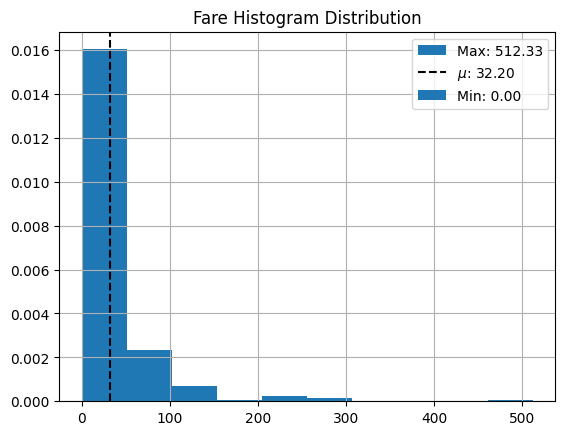

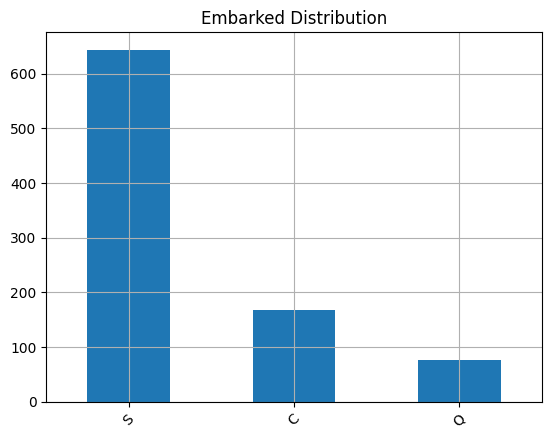

Skipped features due to too many categories: ['Name', 'Ticket', 'Cabin']


###### Feature Variances #####
1. PassengerId     = 6.623e+04
2. Fare            = 2.469e+03
3. Age             = 2.110e+02
4. SibSp           = 1.216e+00
5. Pclass          = 6.990e-01
6. Parch           = 6.497e-01
7. Survived        = 2.368e-01


###### Correlation Study #####


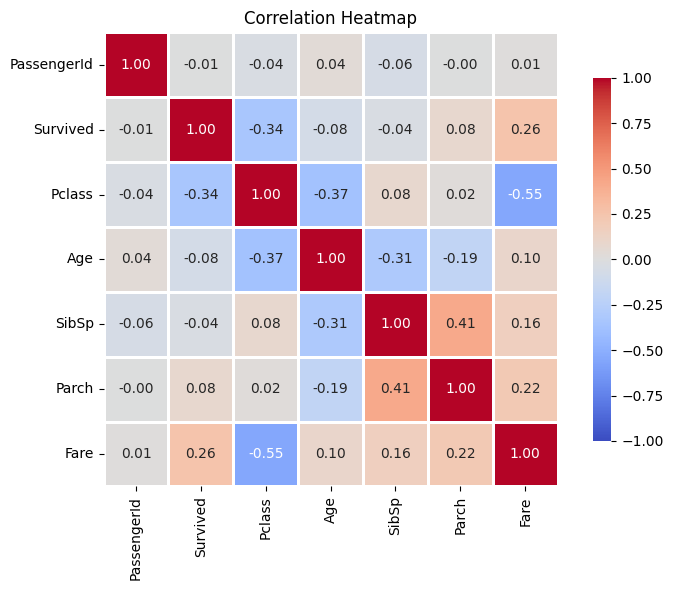



###### Pair Plot #####


<Figure size 800x600 with 0 Axes>

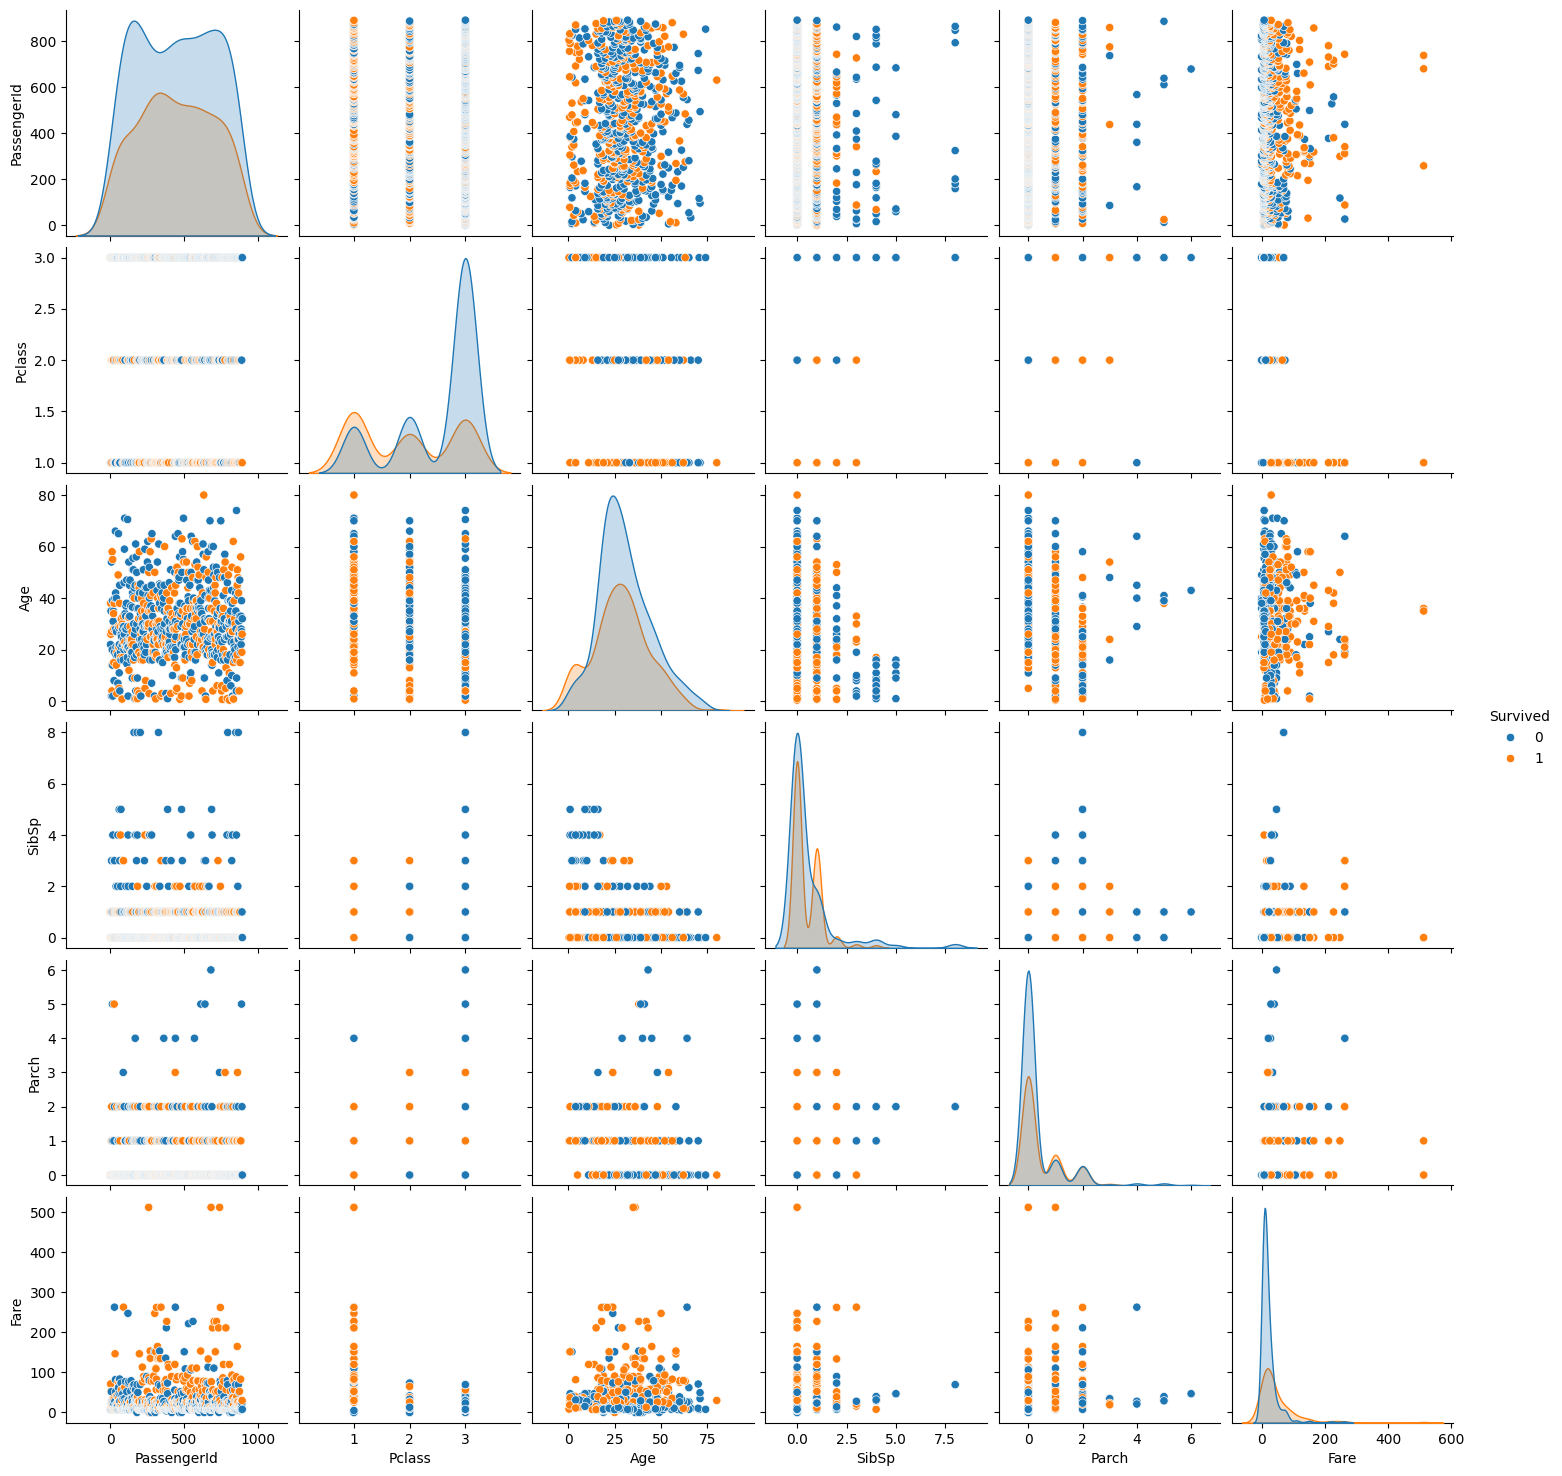

In [25]:
eda(df, "Survived")